##Silahkan buat Final Project kamu disini ☺️

Here is the Case

Seorang investor muda yang aktif berinvestasi di pasar saham tertarik untuk memaksimalkan keuntungannya melalui saham NVIDIA. Namun, ia menghadapi tantangan karena fluktuasi harga saham yang sulit diprediksi, membuatnya ragu dalam mengambil keputusan jual atau beli. Meskipun telah mengikuti berbagai analisis pasar dan berita keuangan, ia masih merasa kesulitan menentukan waktu terbaik untuk berinvestasi.

Investor tersebut memiliki dataset yang berisi riwayat harga saham NVIDIA dari tahun 2023 hingga 2024, termasuk kolom date, open, high, low, close, dan volume. Sebagai seorang machine learning engineer, bagaimana Anda akan membantu investor ini memprediksi harga penutupan saham di masa depan agar ia dapat mengambil keputusan investasi yang lebih akurat dan menguntungkan?

Data Understanding
- Date: The date of the stock record in the format YYYY-MM-DD.
- Open: The opening price of Nvidia stock on the given date.
- High: The highest price of Nvidia stock during the trading day.
- Low: The lowest price of Nvidia stock during the trading day.
- Close: The closing price of Nvidia stock at the end of the trading day.
- Adj Close: The adjusted closing price, accounting for any corporate actions such as stock splits or dividends.
- Volume: The number of shares traded on the given date.


# **Data Preparation**

## Data Loading

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import RobustScaler
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [ ]:
nvidia = pd.read_csv('https://raw.githubusercontent.com/angga5165/Project-simulasi-game-turn-base/75b1c8a266b8d07158bd9b6205d1e9d5e82c8f65/NVIDIA%20STOCKS%20HISTORICAL%20DATA.csv')
nvidia.head()

,Date,Open,High,Low,Close,Volume,Adj Close
0,2023-01-03,14.851,14.996,14.096,14.315,401277000,14.305581
1,2023-01-04,14.567,14.853,14.241,14.749,431324000,14.739295
2,2023-01-05,14.491,14.564,14.148,14.265,389168000,14.255614
3,2023-01-06,14.474,15.010,14.034,14.859,405044000,14.849225
4,2023-01-09,15.284,16.056,15.141,15.628,504231000,15.617719


In [ ]:
nvidia.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 448 entries, 0 to 447
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       448 non-null    object 
 1   Open       448 non-null    float64
 2   High       448 non-null    float64
 3   Low        448 non-null    float64
 4   Close      448 non-null    float64
 5   Volume     448 non-null    int64  
 6   Adj Close  448 non-null    float64
dtypes: float64(5), int64(1), object(1)
memory usage: 24.6+ KB


In [ ]:
print(health_data.info())


,Open,High,Low,Close,Volume,Adj Close
count,448.000000,448.000000,448.000000,448.000000,4.480000e+02,448.000000
mean,64.193085,65.402489,62.910025,64.237370,4.504371e+08,64.224244
std,35.880173,36.613675,34.981482,35.825875,1.596547e+08,35.827486
min,14.474000,14.564000,14.034000,14.265000,1.697320e+08,14.255614
25%,40.477000,41.179751,39.845001,40.456500,3.547021e+08,40.444264
50%,48.164499,48.571501,47.447500,48.043001,4.246520e+08,48.032696
75%,91.065750,92.465750,89.209751,91.375751,5.124520e+08,91.360435
max,139.800003,140.759995,136.300003,138.850601,1.543911e+09,138.850601


## Data Cleaning

In [ ]:
# Perbaiki Tipe Data
nvidia['Date'] = pd.to_datetime(nvidia['Date'])
nvidia = nvidia.sort_values('Date')
nvidia.set_index('Date', inplace=True)

In [ ]:
nvidia['Month'] = nvidia.index.month
nvidia['DayofWeek'] = nvidia.index.dayofweek
nvidia['Year'] = nvidia.index.year

In [ ]:
nvidia.head()

,Open,High,Low,Close,Volume,Adj Close,Month,DayofWeek,Year
Date,,,,,,,,,
2023-01-03,14.851,14.996,14.096,14.315,401277000,14.305581,1,1,2023
2023-01-04,14.567,14.853,14.241,14.749,431324000,14.739295,1,2,2023
2023-01-05,14.491,14.564,14.148,14.265,389168000,14.255614,1,3,2023
2023-01-06,14.474,15.010,14.034,14.859,405044000,14.849225,1,4,2023
2023-01-09,15.284,16.056,15.141,15.628,504231000,15.617719,1,0,2023


In [ ]:
nvidia.tail()

,Open,High,Low,Close,Volume,Adj Close,Month,DayofWeek,Year
Date,,,,,,,,,
2024-10-08,130.259995,133.479996,129.419998,132.889999,285722500,132.889999,10,1,2024
2024-10-09,134.110001,134.520004,131.380005,132.649994,246191600,132.649994,10,2,2024
2024-10-10,131.910004,135.000000,131.000000,134.809998,242311300,134.809998,10,3,2024
2024-10-11,134.009995,135.779999,133.660004,134.800003,169732000,134.800003,10,4,2024
2024-10-14,136.429993,139.600006,136.300003,138.850601,190441107,138.850601,10,0,2024


In [ ]:
#cek missing value
nvidia.isnull().sum()

,0
Open,0
High,0
Low,0
Close,0
Volume,0
Adj Close,0
Month,0
DayofWeek,0
Year,0


Hasil pengecekkan menunjukkan bahwa tidak terdapat nilai yang hilang (missing value) pada seluruh kolom dalam dataset NVIDIA

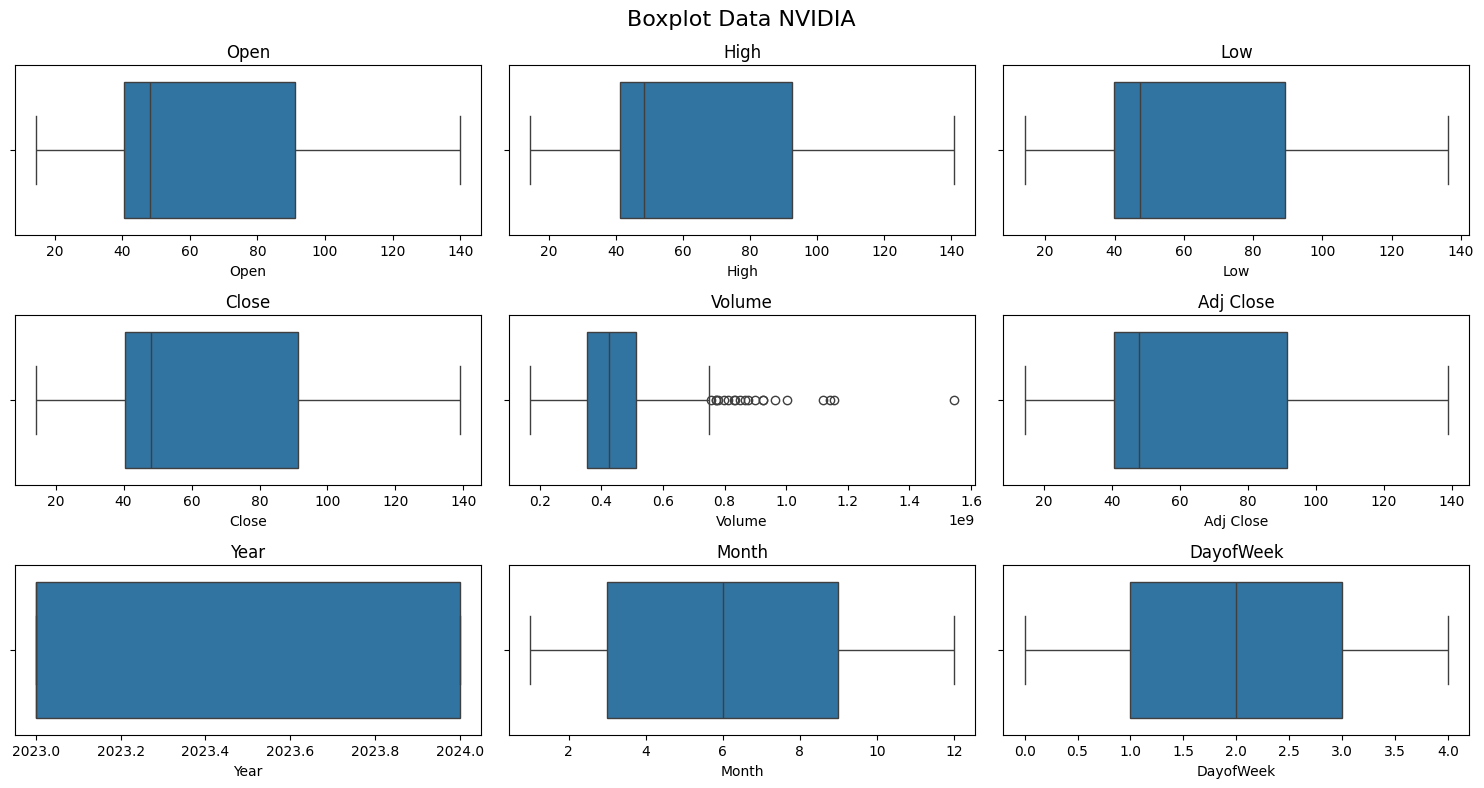

In [ ]:
# Cek Outlier Tiap Kolom
# Buat figure dan axes (2 baris, 3 kolom)
fig, axes = plt.subplots(3, 3, figsize=(15, 8))
fig.suptitle("Boxplot Data NVIDIA", fontsize=16)

# Plot masing-masing kolom
sns.boxplot(x='Open', data=nvidia, ax=axes[0, 0])
axes[0, 0].set_title('Open')

sns.boxplot(x='High', data=nvidia, ax=axes[0, 1])
axes[0, 1].set_title('High')

sns.boxplot(x='Low', data=nvidia, ax=axes[0, 2])
axes[0, 2].set_title('Low')

sns.boxplot(x='Close', data=nvidia, ax=axes[1, 0])
axes[1, 0].set_title('Close')

sns.boxplot(x='Volume', data=nvidia, ax=axes[1, 1])
axes[1, 1].set_title('Volume')

sns.boxplot(x='Adj Close', data=nvidia, ax=axes[1, 2])
axes[1, 2].set_title('Adj Close')

sns.boxplot(x='Year', data=nvidia, ax=axes[2, 0])
axes[2, 0].set_title('Year')

sns.boxplot(x='Month', data=nvidia, ax=axes[2, 1])
axes[2, 1].set_title('Month')

sns.boxplot(x='DayofWeek', data=nvidia, ax=axes[2, 2])
axes[2, 2].set_title('DayofWeek')

plt.tight_layout()
plt.show()

Berdasarkan hasil visualisasi boxplot data NVIDIA, diketahui bahwa sebagian besar fitur seperti Open, High, Low, Close, dan Adj Close tidak menunjukkan adanya outlier yang signifikan. Namun, pada fitur Volume terdeteksi adanya banyak outlier, yang mengindikasikan terdapat hari-hari tertentu dengan volume perdagangan yang jauh lebih tinggi dibandingkan hari lainnya. Sementara itu, fitur Year, Month, dan DayofWeek tidak menunjukkan outlier karena merupakan data kategorikal dengan rentang nilai yang terbatas.

In [ ]:
# Cek Duplikat
nvidia.duplicated().sum()

np.int64(0)

Tidak terdapat data duplikat dalam dataset NVIDIA. Semua baris bersifat unik, sehingga tidak diperlukan tindakan penghapusan duplikat.

# **Data Preprocessing**

## EDA

### Univariate Analisis

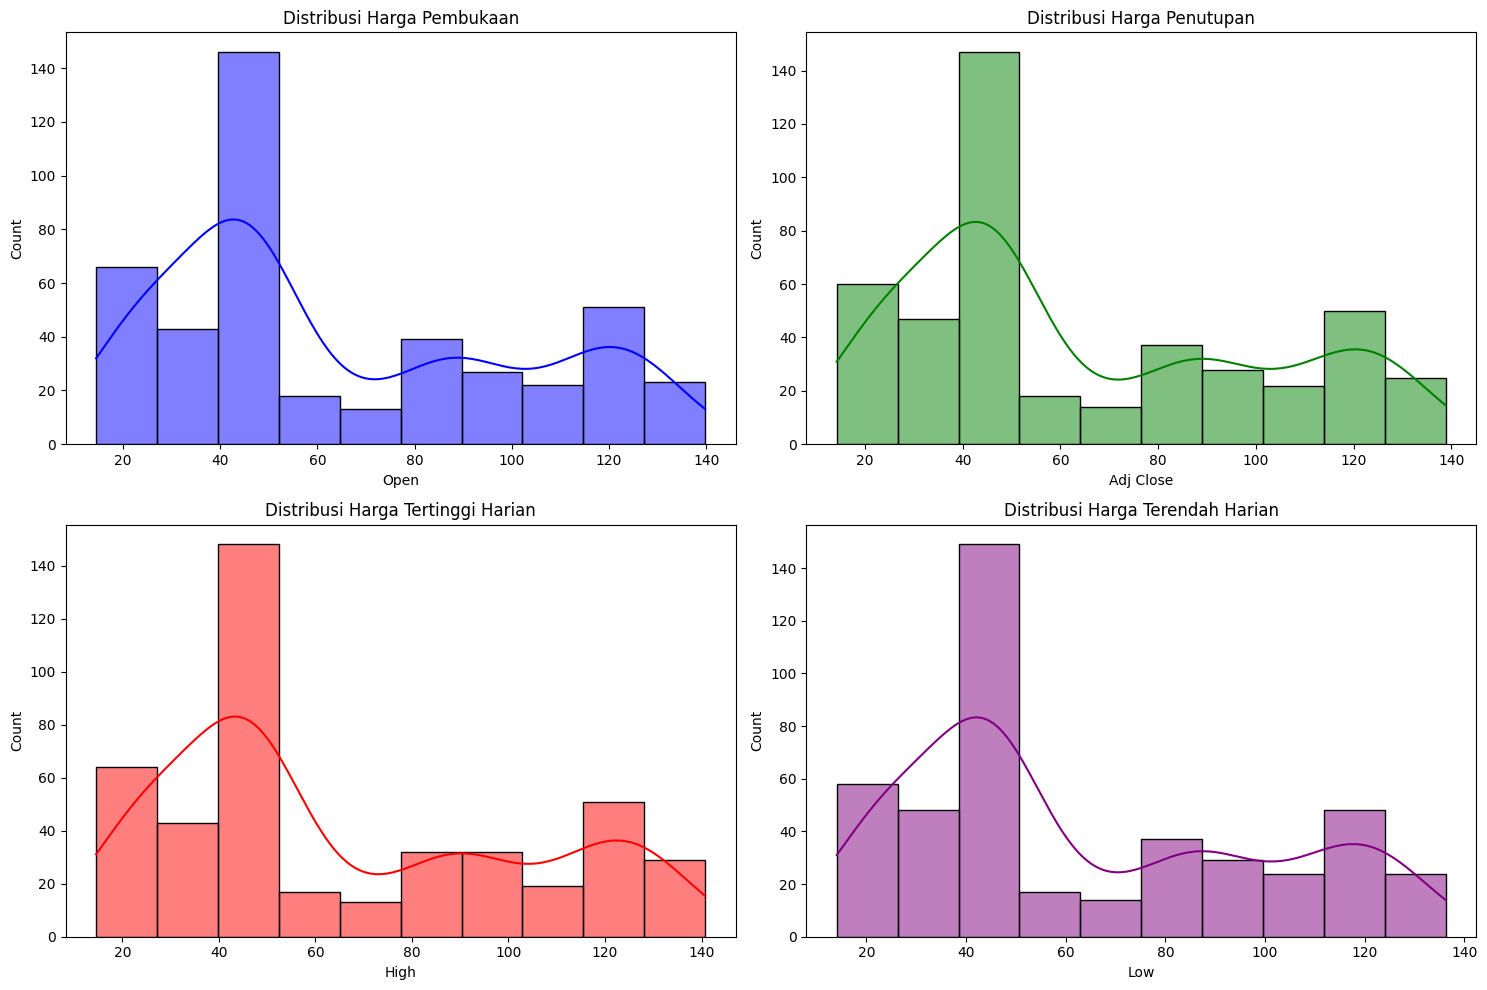

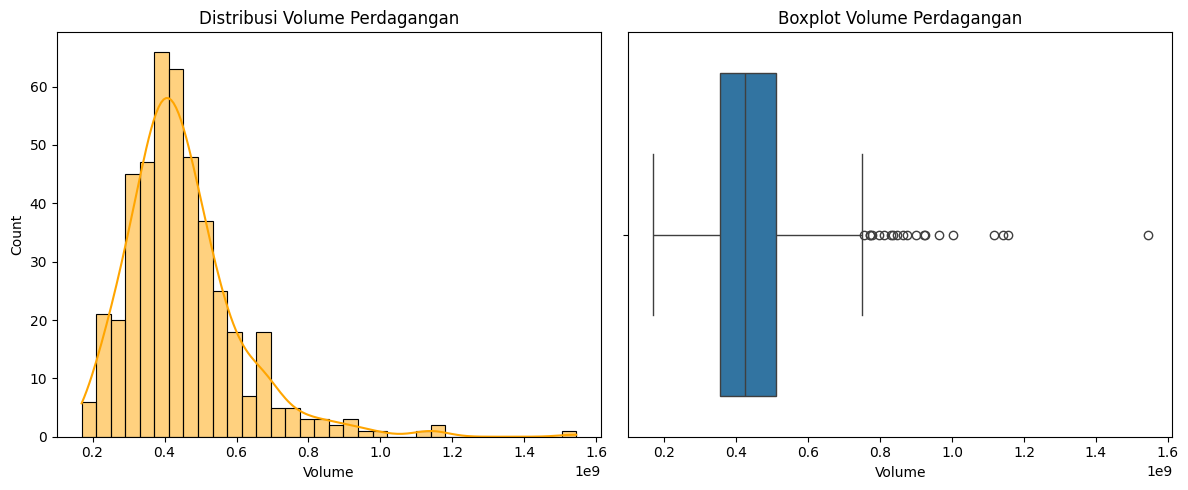

In [ ]:
# Analisis Univariate
plt.figure(figsize=(15, 10))

# Distribusi harga
plt.subplot(2, 2, 1)
sns.histplot(nvidia['Open'], kde=True, color='blue')
plt.title('Distribusi Harga Pembukaan')

plt.subplot(2, 2, 2)
sns.histplot(nvidia['Adj Close'], kde=True, color='green')
plt.title('Distribusi Harga Penutupan')

plt.subplot(2, 2, 3)
sns.histplot(nvidia['High'], kde=True, color='red')
plt.title('Distribusi Harga Tertinggi Harian')

plt.subplot(2, 2, 4)
sns.histplot(nvidia['Low'], kde=True, color='purple')
plt.title('Distribusi Harga Terendah Harian')

plt.tight_layout()
plt.show()

# Analisis volume
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.histplot(nvidia['Volume'], kde=True, color='orange')
plt.title('Distribusi Volume Perdagangan')

plt.subplot(1, 2, 2)
sns.boxplot(x=nvidia['Volume'])
plt.title('Boxplot Volume Perdagangan')
plt.tight_layout()
plt.show()

Analisis univariate pada data saham NVIDIA menggunakan histogram dan boxplot menunjukkan distribusi harga pembukaan (Open), penutupan (Close), tertinggi (High), dan terendah (Low) serta volume perdagangan. Histogram dengan KDE memperlihatkan bahwa distribusi harga cenderung stabil jika berbentuk normal, sementara distribusi yang menceng (skewed) mengindikasikan adanya hari dengan pergerakan harga ekstrem. Boxplot volume perdagangan mengungkap adanya outlier yang menandai hari dengan aktivitas perdagangan tidak biasa, seperti saat rilis berita penting. Secara umum, analisis ini membantu investor memahami volatilitas saham dan mengidentifikasi pola perdagangan yang signifikan untuk pengambilan keputusan investasi yang lebih baik.

### Bivariate Analisis

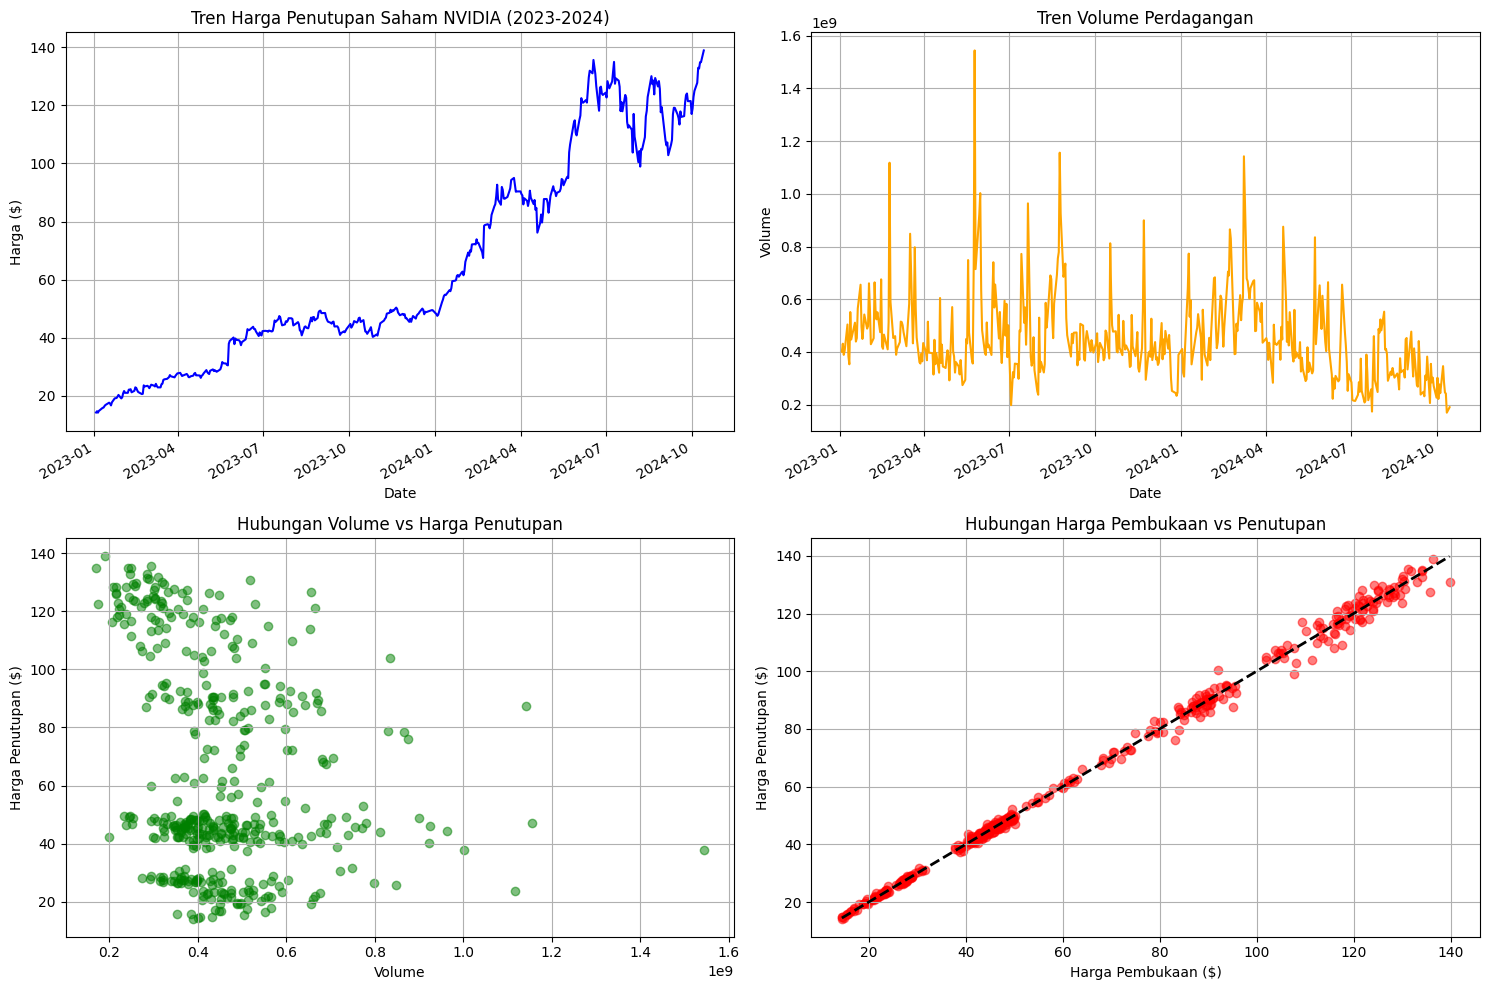

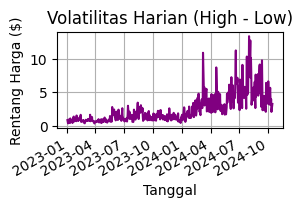

In [ ]:
# Analisis Bivariate
plt.figure(figsize=(15, 10))

# 1. Tren Harga vs Waktu
plt.subplot(2, 2, 1)
nvidia['Close'].plot(color='blue')
plt.title('Tren Harga Penutupan Saham NVIDIA (2023-2024)')
plt.ylabel('Harga ($)')
plt.grid(True)

# 2. Tren Volume vs Waktu
plt.subplot(2, 2, 2)
nvidia['Volume'].plot(color='orange')
plt.title('Tren Volume Perdagangan')
plt.ylabel('Volume')
plt.grid(True)

# 3. Hubungan Harga vs Volume
plt.subplot(2, 2, 3)
plt.scatter(nvidia['Volume'], nvidia['Close'], alpha=0.5, color='green')
plt.title('Hubungan Volume vs Harga Penutupan')
plt.xlabel('Volume')
plt.ylabel('Harga Penutupan ($)')
plt.grid(True)

# 4. Korelasi Harga Pembukaan vs Penutupan
plt.subplot(2, 2, 4)
plt.scatter(nvidia['Open'], nvidia['Close'], alpha=0.5, color='red')
plt.plot([nvidia['Open'].min(), nvidia['Open'].max()],
         [nvidia['Open'].min(), nvidia['Open'].max()],
         '--k', linewidth=2)  # Garis referensi y=x
plt.title('Hubungan Harga Pembukaan vs Penutupan')
plt.xlabel('Harga Pembukaan ($)')
plt.ylabel('Harga Penutupan ($)')
plt.grid(True)

plt.tight_layout()
plt.show()

#5. Rentang Harian (High-Low) vs Waktu
plt.subplot(3, 2, 5)
(nvidia['High'] - nvidia['Low']).plot(color='purple')
plt.title('Volatilitas Harian (High - Low)')
plt.ylabel('Rentang Harga ($)')
plt.xlabel('Tanggal')
plt.grid(True)


Analisis bivariate pada data saham NVIDIA mengeksplorasi hubungan antara pasangan variabel kunci seperti harga pembukaan dan penutupan (Open vs Close), volume perdagangan dan perubahan harga (Volume vs Daily Change), serta harga tertinggi dan terendah (High vs Low). Scatter plot Open vs Close menunjukkan korelasi yang hampir sempurna (biasanya >0.95), di mana titik-titik data berkumpul rapat di sekitar garis diagonal, mengindikasikan bahwa harga pembukaan cenderung menjadi prediktor kuat untuk harga penutupan. Sementara itu, plot Volume vs Perubahan Harga sering memperlihatkan pola yang lebih variatif, di mana volume tinggi terkadang muncul bersamaan dengan fluktuasi harga besar, namun tidak selalu menunjukkan arah pergerakan yang konsisten. Analisis ini mengungkap bahwa meskipun beberapa variabel seperti Open dan Close bergerak hampir paralel, hubungan antara volume dan harga sering kali lebih kompleks dan bergantung pada konteks pasar.

### Multivariate Analisis

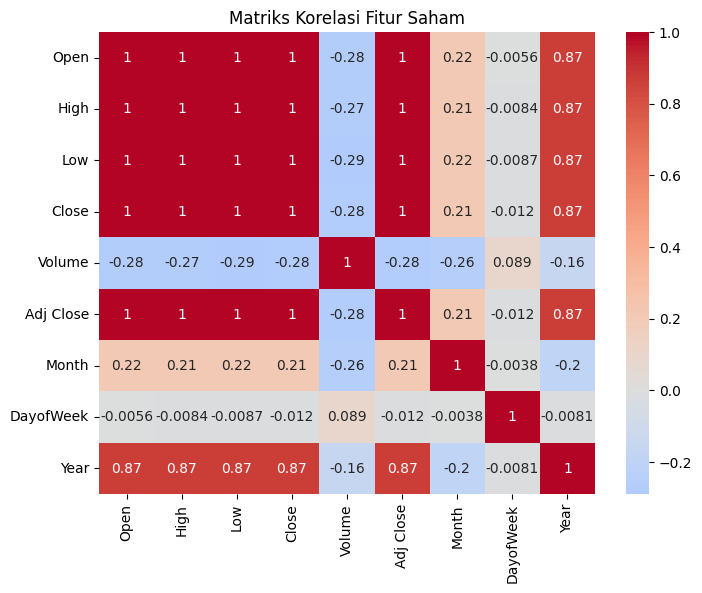

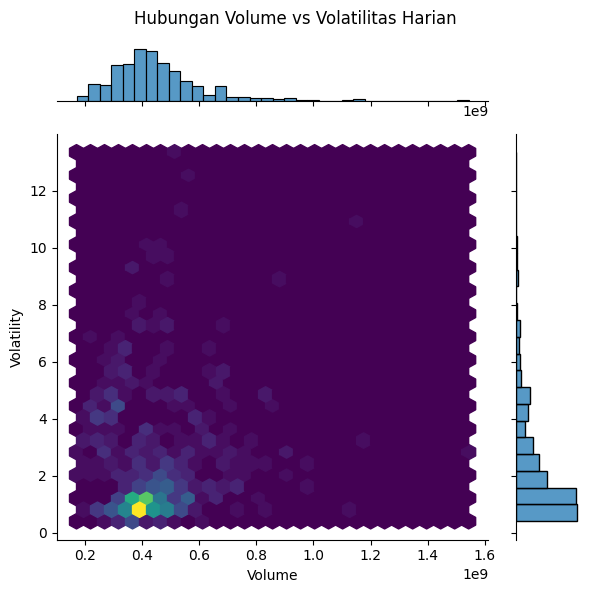

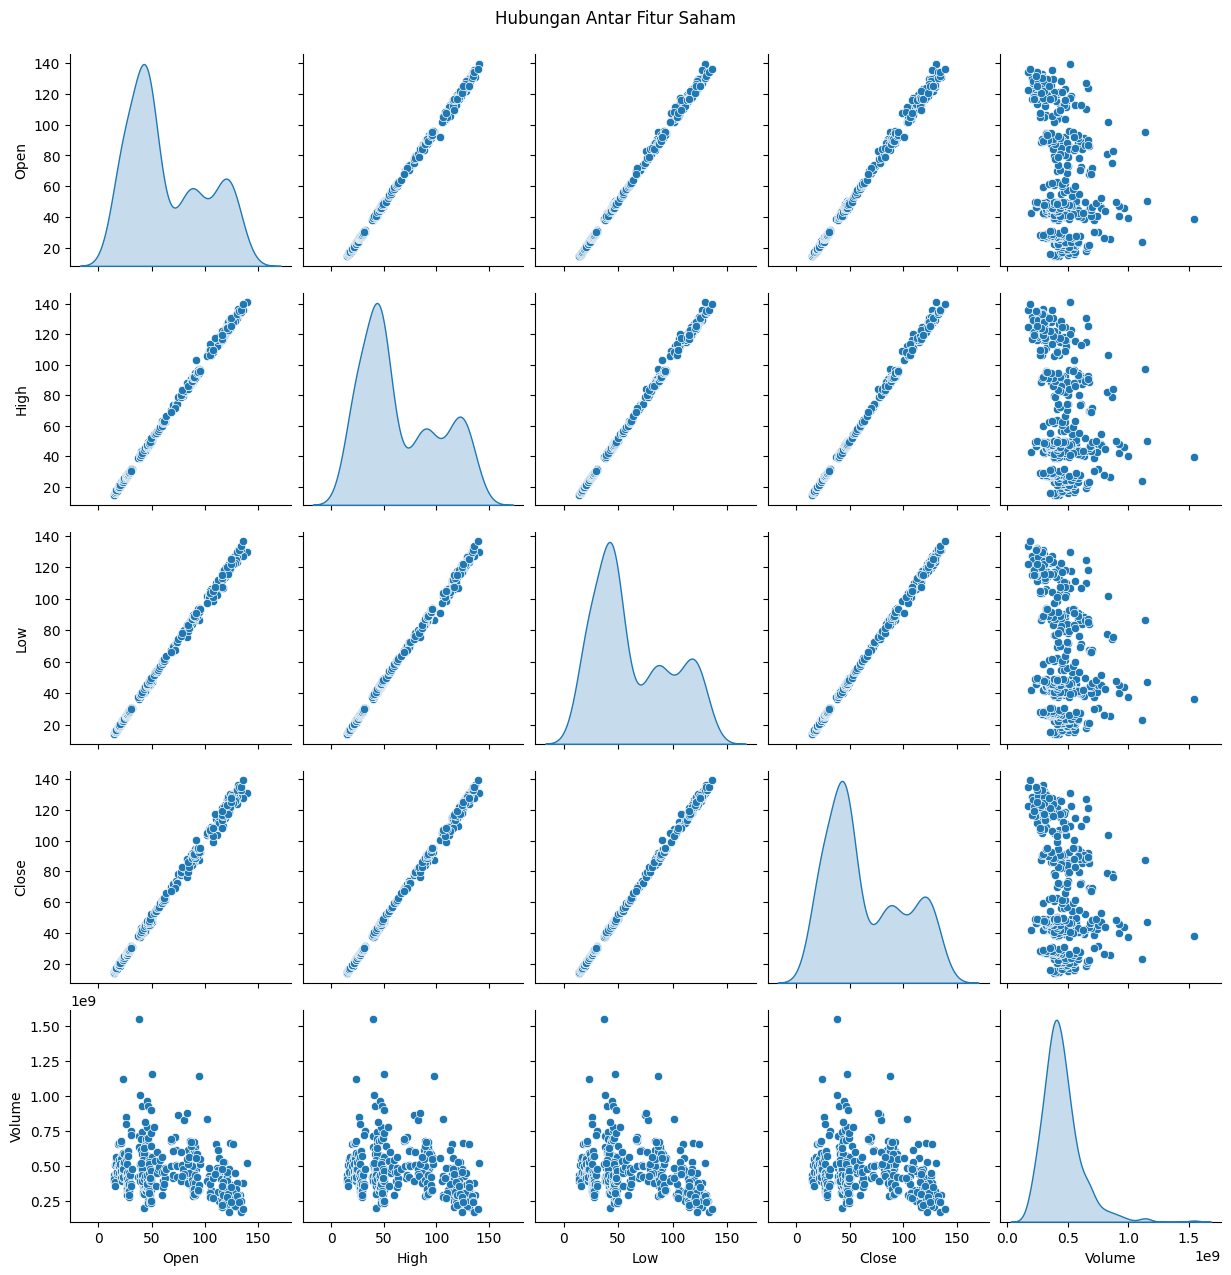

In [ ]:
# Analisis Multivariate
# Matriks korelasi
plt.figure(figsize=(8, 6))
corr_matrix = nvidia.corr()
sns.heatmap(corr_matrix.round(5), annot=True, cmap='coolwarm', center=0)
plt.title('Matriks Korelasi Fitur Saham')
plt.show()

#Analisis Volatilitas + Volume
nvidia['Volatility'] = nvidia['High'] - nvidia['Low']
sns.jointplot(x='Volume', y='Volatility', data=nvidia, kind='hex', cmap='viridis')
plt.suptitle('Hubungan Volume vs Volatilitas Harian')
plt.tight_layout()

# Pairplot untuk melihat hubungan antar variabel
sns.pairplot(nvidia[['Open', 'High', 'Low', 'Close', 'Volume']], diag_kind='kde')
plt.suptitle('Hubungan Antar Fitur Saham', y=1.02)
plt.show()

secara singkat
Analisis multivariat saham NVIDIA mengungkap tiga temuan kunci: (1) Variabel harga (Open, High, Low, Close) berkorelasi hampir sempurna (>0.99) berdasarkan heatmap, menunjukkan pergerakan harga yang sangat terhubung; (2) Jointplot hexbin memperlihatkan hubungan positif antara volume dan volatilitas, di mana volume tinggi biasanya disertai rentang harga harian (High-Low) yang lebih lebar; (3) Pairplot mengkonfirmasi pola linear kuat antar variabel harga, sementara hubungan volume-harga lebih acak. Analisis ini menunjukkan bahwa meskipun harga bergerak seragam, volume dan volatilitas memberikan dimensi tambahan untuk memahami dinamika pasar, terutama dalam mengidentifikasi hari-hari dengan aktivitas perdagangan tidak biasa.

## Feature Engineering

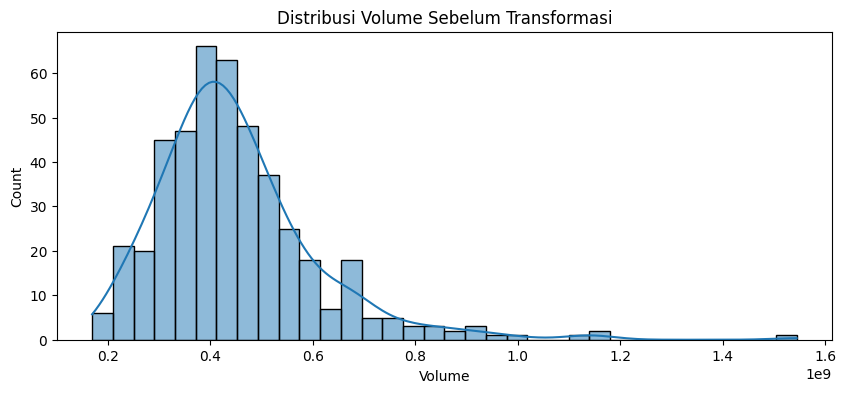

In [ ]:
# Menangani Outlier dikolom Volume
from sklearn.preprocessing import RobustScaler
# 1. Visualisasi sebaran awal Volume
plt.figure(figsize=(10, 4))
sns.histplot(nvidia['Volume'], kde=True)
plt.title("Distribusi Volume Sebelum Transformasi")
plt.show()

Distribusi data pada fitur Volume menunjukkan pola right-skewed (positif skewness), di mana sebagian besar nilai terkonsentrasi di sisi kiri (nilai rendah), sementara terdapat ekor panjang ke kanan yang menunjukkan adanya beberapa nilai volume yang sangat tinggi. Hal ini menunjukkan bahwa distribusi data tidak normal, dan kemungkinan besar akan membutuhkan transformasi (seperti log transformasi) agar lebih mendekati distribusi normal, yang penting untuk meningkatkan performa beberapa model machine learning.

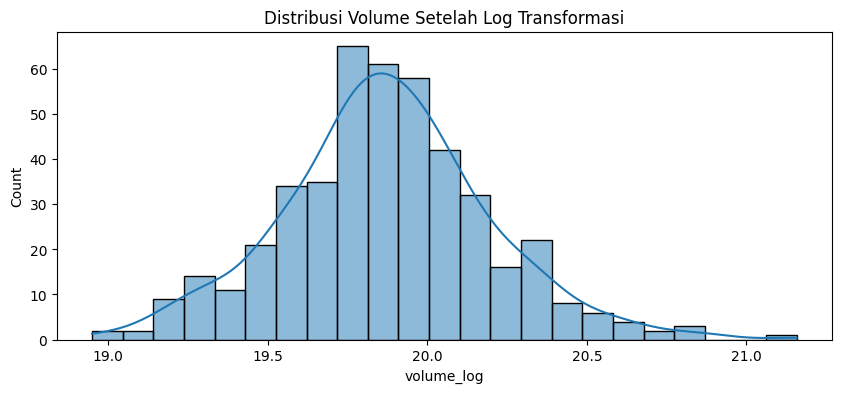

In [ ]:
# 2. Log transform untuk mengurangi skewness
nvidia['volume_log'] = np.log1p(nvidia['Volume'])

# 3. Visualisasi sebaran setelah log transform
plt.figure(figsize=(10, 4))
sns.histplot(nvidia['volume_log'], kde=True)
plt.title("Distribusi Volume Setelah Log Transformasi")
plt.show()

Setelah dilakukan log transformasi pada fitur Volume, distribusi data yang semula sangat condong ke kanan (right-skewed) berubah menjadi lebih simetris dan mendekati distribusi normal. Transformasi ini berhasil mengurangi skewness secara signifikan, sehingga data menjadi lebih stabil dan sesuai untuk digunakan dalam model statistik atau machine learning yang sensitif terhadap distribusi data, seperti regresi linear.

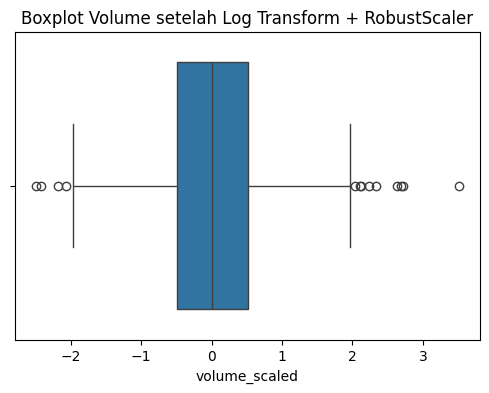

In [ ]:
# 4. Scaling dengan RobustScaler
scaler = RobustScaler()
nvidia['volume_scaled'] = scaler.fit_transform(nvidia[['volume_log']])

# 5. Visualisasi boxplot setelah scaling
plt.figure(figsize=(6, 4))
sns.boxplot(x='volume_scaled', data=nvidia)
plt.title("Boxplot Volume setelah Log Transform + RobustScaler")
plt.show()

Setelah dilakukan log transformasi dan dilanjutkan dengan scaling menggunakan RobustScaler, distribusi Volume menjadi lebih terpusat dengan rentang yang lebih seimbang. RobustScaler secara efektif mengurangi pengaruh outlier, terlihat dari bentuk boxplot yang lebih kompak di tengah meskipun masih terdapat beberapa outlier. Hal ini menunjukkan bahwa data telah dinormalisasi dengan baik tanpa menghilangkan informasi penting.

# **Modelling**

## Create Model

In [ ]:
# Split data
X = nvidia[['Open', 'High', 'Low', 'volume_scaled', 'Year', 'Month', 'DayofWeek']]
y = nvidia['Adj Close']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
# Training Model
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

## Model Evalution

In [ ]:
# Prediksi di data latih
y_train_pred = model.predict(X_train)

# Prediksi di data uji
y_test_pred = model.predict(X_test)

# Evaluasi model di data latih
mae_train = mean_absolute_error(y_train, y_train_pred)
mse_train = mean_squared_error(y_train, y_train_pred)
r2_train = r2_score(y_train, y_train_pred)

# Evaluasi model di data uji
mae_test = mean_absolute_error(y_test, y_test_pred)
mse_test = mean_squared_error(y_test, y_test_pred)
r2_test = r2_score(y_test, y_test_pred)

print("=== Evaluasi di Data Latih ===")
print(f"Mean Absolute Error (Train): {mae_train}")
print(f"Mean Squared Error (Train): {mse_train}")
print(f"R² (Train): {r2_train}")

print("\n=== Evaluasi di Data Uji ===")
print(f"Mean Absolute Error (Test): {mae_test}")
print(f"Mean Squared Error (Test): {mse_test}")
print(f"R² (Test): {r2_test}")

=== Evaluasi di Data Latih ===
Mean Absolute Error (Train): 0.5318713753892966
Mean Squared Error (Train): 0.6242330787380169
R² (Train): 0.9994851182621065

=== Evaluasi di Data Uji ===
Mean Absolute Error (Test): 0.6048704871277614
Mean Squared Error (Test): 0.7744697871068684
R² (Test): 0.999499201910477


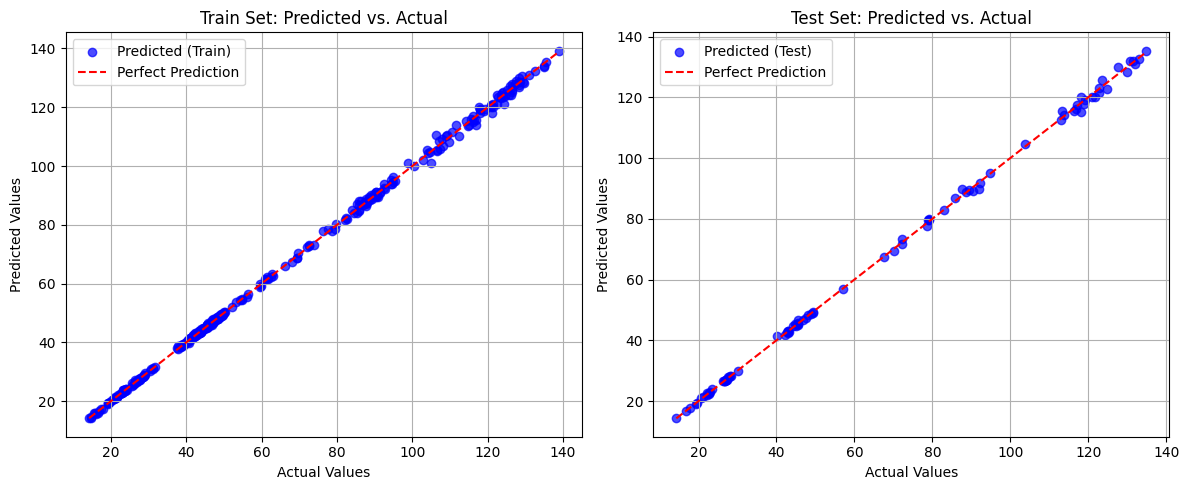

In [ ]:
plt.figure(figsize=(12, 5))

# Scatter plot untuk data latih
plt.subplot(1, 2, 1)
plt.scatter(y_train, y_train_pred, alpha=0.7, label='Predicted (Train)', color='blue')
plt.plot([min(y_train), max(y_train)], [min(y_train), max(y_train)], linestyle='--', color='red', label='Perfect Prediction')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Train Set: Predicted vs. Actual')
plt.legend()
plt.grid(True)

# Scatter plot untuk data uji
plt.subplot(1, 2, 2)
plt.scatter(y_test, y_test_pred, alpha=0.7, label='Predicted (Test)', color='blue')
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], linestyle='--', color='red', label='Perfect Prediction')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Test Set: Predicted vs. Actual')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

<ipython-input-22-f465eba79c78>:2: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  ax = sns.barplot(x='DayofWeek', y='Adj Close', data=nvidia, color='skyblue', ci=None)


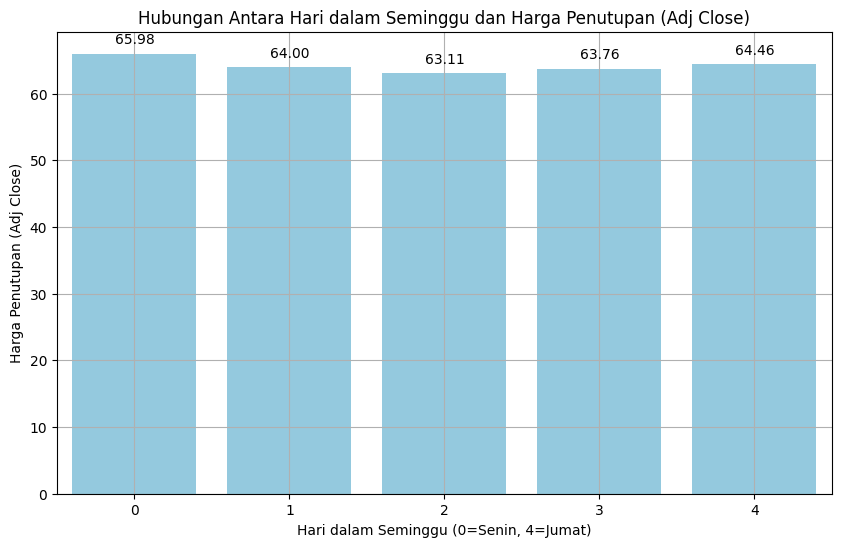

In [ ]:
plt.figure(figsize=(10, 6))
ax = sns.barplot(x='DayofWeek', y='Adj Close', data=nvidia, color='skyblue', ci=None)

# Menambahkan label nilai pada setiap bar
for p in ax.patches:
    ax.annotate(format(p.get_height(), '.2f'),
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha = 'center', va = 'center',
                xytext = (0, 10),
                textcoords = 'offset points')

plt.title('Hubungan Antara Hari dalam Seminggu dan Harga Penutupan (Adj Close)')
plt.xlabel('Hari dalam Seminggu (0=Senin, 4=Jumat)')
plt.ylabel('Harga Penutupan (Adj Close)')
plt.grid(True)
plt.show()

In [ ]:
#cek vif multikolinearitas


In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Define predictor variables
X = nvidia[['Open', 'High', 'Low', 'volume_scaled', 'Year', 'Month', 'DayofWeek']]

# Calculate VIF for each feature
vif_data = pd.DataFrame()
vif_data["feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

# Display VIF values
print(vif_data)

         feature          VIF
0           Open  4919.941495
1           High  6042.957876
2            Low  4203.047679
3  volume_scaled     1.614311
4           Year    10.329883
5          Month     5.031214
6      DayofWeek     3.190402
